In [1]:
 !git clone -b Exam_Project https://github.com/filipani/Data_Processing_And_Analysis_UniCourse.git

Cloning into 'Data_Processing_And_Analysis_UniCourse'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 106 (delta 37), reused 28 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (106/106), 2.96 MiB | 11.63 MiB/s, done.
Resolving deltas: 100% (37/37), done.


In [2]:
#loading the data
import pandas as pd


columns = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
    'ring-type', 'spore-print-color', 'population', 'habitat'
]

# Prova questo percorso esatto
df = pd.read_csv('/content/Data_Processing_And_Analysis_UniCourse/agaricus-lepiota.data', names=columns)


print(df.shape)
df.head()

(8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [1]:
#loading the data usando vscode
import pandas as pd


columns = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
    'ring-type', 'spore-print-color', 'population', 'habitat'
]

# Prova questo percorso esatto
df = pd.read_csv('agaricus-lepiota.data', names=columns)

print(df.shape)
df.head()

(8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [2]:
# exploratory data analysis

print('=== dtypes ===')
print(df.dtypes)
print('\n=== missing values ===')
print(df.isnull().sum())
print('\n=== value counts for stalk-root ===')
print(df['stalk-root'].value_counts())
print('\n=== describe (numeric) ===')
print(df.describe())
print('\n=== class distribution ===')
print(df['class'].value_counts(normalize=True))

=== dtypes ===
class                       str
cap-shape                   str
cap-surface                 str
cap-color                   str
bruises                     str
odor                        str
gill-attachment             str
gill-spacing                str
gill-size                   str
gill-color                  str
stalk-shape                 str
stalk-root                  str
stalk-surface-above-ring    str
stalk-surface-below-ring    str
stalk-color-above-ring      str
stalk-color-below-ring      str
veil-type                   str
veil-color                  str
ring-number                 str
ring-type                   str
spore-print-color           str
population                  str
habitat                     str
dtype: object

=== missing values ===
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
g

In [3]:
import pandas as pd
from scipy.stats import chi2_contingency


df['is_missing'] = df['stalk-root'] == '?'


def check_mcar(data, target_col):
    results = []
    columns_to_test = [c for c in data.columns if c not in [target_col, 'is_missing']]

    for col in columns_to_test:

        contingency_table = pd.crosstab(data[col], data['is_missing'])


        chi2, p, dof, ex = chi2_contingency(contingency_table)

        results.append({
            'Variabile': col,
            'p-value': round(p, 10),
            'Dipendente (Not MCAR)': p < 0.05
        })

    return pd.DataFrame(results)



mcar_report = check_mcar(df, 'stalk-root')
print(mcar_report.sort_values(by='p-value'))

df.drop(columns=['is_missing'], inplace=True)

                   Variabile  p-value  Dipendente (Not MCAR)
0                      class      0.0                   True
1                  cap-shape      0.0                   True
2                cap-surface      0.0                   True
3                  cap-color      0.0                   True
4                    bruises      0.0                   True
5                       odor      0.0                   True
6            gill-attachment      0.0                   True
7               gill-spacing      0.0                   True
8                  gill-size      0.0                   True
9                 gill-color      0.0                   True
10               stalk-shape      0.0                   True
11  stalk-surface-above-ring      0.0                   True
12  stalk-surface-below-ring      0.0                   True
13    stalk-color-above-ring      0.0                   True
14    stalk-color-below-ring      0.0                   True
16                veil-c

In [ ]:
#df_reduced = df.drop(columns=['stalk-root'])

In [4]:

unique_counts = df.nunique()

print("Conteggio valori unici per colonna:")
print(unique_counts)


cols_to_drop = unique_counts[unique_counts == 1].index.tolist()

print(f"\n--- Colonne da rimuovere (Varianza Zero): {cols_to_drop} ---")

Conteggio valori unici per colonna:
class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64

--- Colonne da rimuovere (Varianza Zero): ['veil-type'] ---


In [5]:
# Rimuoviamo le colonne con varianza zero

def check_nzv(data, threshold=0.95):
    nzv_report = []
    for col in data.columns:
        # Calcoliamo la frequenza del valore più comune
        most_freq_ratio = data[col].value_counts(normalize=True).iloc[0]
        # Numero di valori unici
        unique_values = data[col].nunique()

        nzv_report.append({
            'Colonna': col,
            'Frequenza Valore Dominante': f"{most_freq_ratio:.2%}",
            'Valori Unici': unique_values,
            'Is_NZV': most_freq_ratio > threshold
        })

    return pd.DataFrame(nzv_report)

# Eseguiamo l'analisi sul dataset pulito precedentemente
report = check_nzv(df)
print(report.sort_values(by='Frequenza Valore Dominante', ascending=False))

                     Colonna Frequenza Valore Dominante  Valori Unici  Is_NZV
17                veil-color                     97.54%             4    True
6            gill-attachment                     97.42%             2    True
18               ring-number                     92.17%             3   False
7               gill-spacing                     83.85%             2   False
8                  gill-size                     69.08%             2   False
12  stalk-surface-above-ring                     63.71%             4   False
13  stalk-surface-below-ring                     60.76%             4   False
4                    bruises                     58.44%             2   False
10               stalk-shape                     56.72%             2   False
14    stalk-color-above-ring                     54.95%             9   False
15    stalk-color-below-ring                     53.96%             9   False
0                      class                     51.80%         

class                       0.998708
stalk-shape                 0.981932
bruises                     0.971479
gill-color                  0.937415
cap-color                   0.889990
cap-surface                 0.880014
habitat                     0.870007
spore-print-color           0.856399
gill-size                   0.854393
stalk-root                  0.833159
odor                        0.814776
population                  0.813940
ring-type                   0.773965
cap-shape                   0.760135
stalk-surface-below-ring    0.724981
stalk-color-below-ring      0.723536
stalk-color-above-ring      0.712526
stalk-surface-above-ring    0.672264
gill-spacing                0.541662
ring-number                 0.217455
gill-attachment             0.100725
veil-color                  0.064467
veil-type                   0.000000
dtype: float64


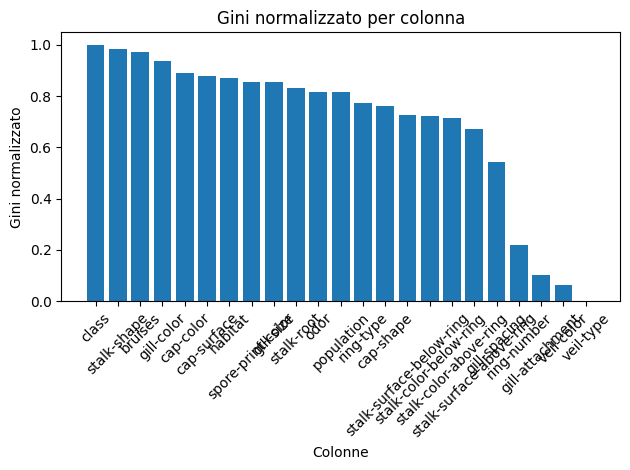

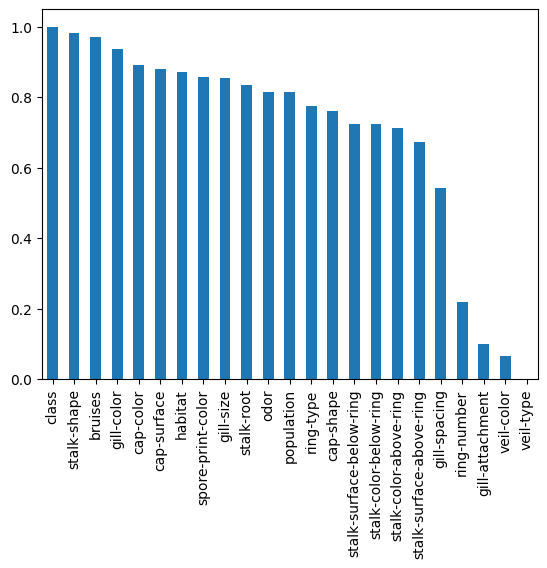

In [12]:
#varianza controllata con gini normalizzato

def gini_normalized(df):
    gini_dict = {}

    for col in df.columns:
        probs = df[col].value_counts(normalize=True, dropna=True)

        gini = 1 - (probs**2).sum()

        k = len(probs)

        if k > 1:
            gini_max = 1 - 1/k
            gini_norm = gini / gini_max
        else:
            gini_norm = 0

        gini_dict[col] = gini_norm

    return pd.Series(gini_dict).sort_values(ascending=False)


gini_scores = gini_normalized(df)
print(gini_scores)

import matplotlib.pyplot as plt

gini_scores = gini_normalized(df)

plt.figure()
plt.bar(gini_scores.index, gini_scores.values)
plt.xticks(rotation=45)
plt.xlabel("Colonne")
plt.ylabel("Gini normalizzato")
plt.title("Gini normalizzato per colonna")
plt.tight_layout()
plt.show()

gini_scores.plot(kind='bar')
plt.show()


cols_to_remove = ['veil-type', 'veil-color', 'gill-attachment', 'stalk-root']


df_final = df.drop(columns=cols_to_remove)

print(f"Rimosse {len(cols_to_remove)} colonne.")
print(f"Dataset attuale: {df_final.shape[1]} colonne rimaste.")
print("\nPrime 5 righe del dataset pulito:")
df_final.head()

In [ ]:
#per ora skippare


#from sklearn.preprocessing import LabelEncoder

#df_labeled = df_f
#inal.copy()


#label_encoders = {}

#for col in df_labeled.columns:

 #   le = LabelEncoder()
 #   df_labeled[col] = le.fit_transform(df_labeled[col])
 #   label_encoders[col] = le


#print("--- DATASET FATTORIZZATO ---")
#display(df_labeled.head())


#print("\n" + "="*40)
#print("LEGENDE DELLE VARIABILI (Mapping)")
#print("="*40)

#for col, le in label_encoders.items():

 #   mapping = dict(zip(le.transform(le.classes_), le.classes_))


 #   print(f"\n[ {col.upper()} ]")

 #   for num in sorted(mapping.keys()):
 #       print(f"  {num} : {mapping[num]}")

#print("\n" + "="*40)
#print("FINE REPORT")

In [7]:
#Versione senza eliminare stalk root (missing potrebbero avere un significato) e con dummy

from sklearn.preprocessing import OneHotEncoder


cols_to_remove2 = ['veil-type', 'veil-color', 'gill-attachment', 'ring-number']


df_final2 = df.drop(columns=cols_to_remove2)

print(f"Rimosse {len(cols_to_remove2)} colonne.")
print(f"Dataset attuale: {df_final2.shape[1]} colonne rimaste.")
#print(df_final2.head())

columns = list(df_final2.columns)

encoder = OneHotEncoder(drop='first', sparse_output=False, dtype='int')
encoded_data = encoder.fit_transform(df_final2[columns])
encoded_cols = encoder.get_feature_names_out(columns)
df_encoded = pd.DataFrame(encoded_data, columns=encoded_cols, index=df_final2.index)

print("--- DATASET CON DUMMY VARIABLES ---")
print(f"Forma finale del dataset: {df_encoded.shape}")
print(df_encoded.head())

Rimosse 4 colonne.
Dataset attuale: 19 colonne rimaste.
--- DATASET CON DUMMY VARIABLES ---
Forma finale del dataset: (8124, 90)
   class_p  cap-shape_c  cap-shape_f  cap-shape_k  cap-shape_s  cap-shape_x  \
0        1            0            0            0            0            1   
1        0            0            0            0            0            1   
2        0            0            0            0            0            0   
3        1            0            0            0            0            1   
4        0            0            0            0            0            1   

   cap-surface_g  cap-surface_s  cap-surface_y  cap-color_c  ...  \
0              0              1              0            0  ...   
1              0              1              0            0  ...   
2              0              1              0            0  ...   
3              0              0              1            0  ...   
4              0              1              0          

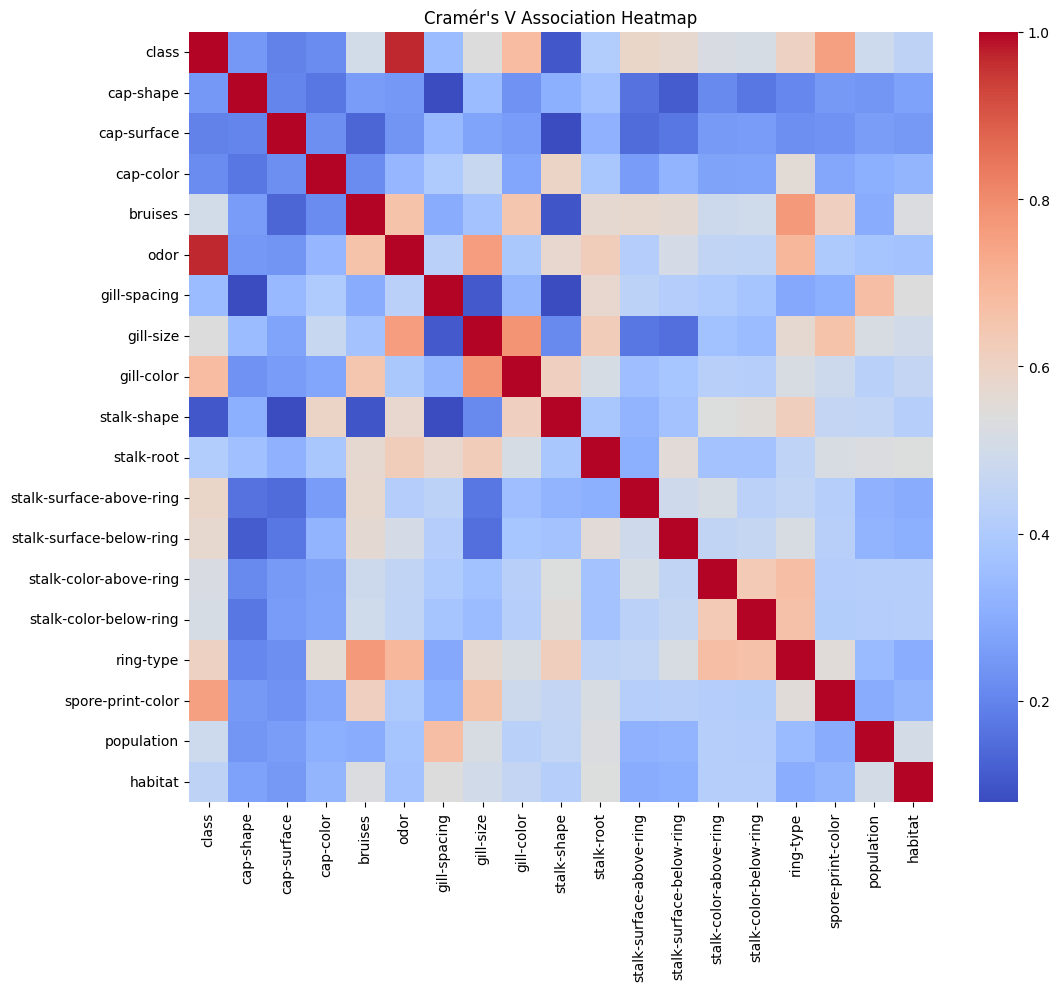

In [8]:
#heatmap delle contingency con Cramér's V

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from matplotlib import pyplot as plt
import seaborn as sns

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r,k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

# Calcolo matrice
cols = df_final2.columns
matrix = pd.DataFrame(index=cols, columns=cols)

for col1 in cols:
    for col2 in cols:
        matrix.loc[col1, col2] = cramers_v(df_final2[col1], df_final2[col2])

matrix = matrix.astype(float)

plt.figure(figsize=(12,10))
sns.heatmap(matrix, cmap='coolwarm')
plt.title("Cramér's V Association Heatmap")
plt.show()

In [9]:
#train-validation split

from sklearn.model_selection import train_test_split

X = df_encoded.drop('class_p', axis=1)
y = df_encoded['class_p']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5686, 89), (2438, 89), (5686,), (2438,))

In [13]:
#random forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, precision_score

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [500],
    'max_depth': [None, 10, 20],
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

#valutazione sul test set
y_pred = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#precision_edible = precision_score(y_test, y_pred, pos_label=0)
#print("Precision (edible, cioè sicurezza nel mangiabile):", precision_edible)

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1263
           1       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



In [14]:
#feature importance

importances = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances)

X_sel=df_encoded.loc[:, importances[:25].index]
X_sel_train, X_sel_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.3, random_state=42, stratify=y
)

X_sel_train.shape, X_sel_test.shape, y_train.shape, y_test.shape


#a fini interpretativi

def get_original_feature(col_name):
    return col_name.split('_')[0]

df_imp = pd.DataFrame({
    'feature': importances.index,
    'importance': importances.values
})

df_imp['original'] = df_imp['feature'].apply(get_original_feature)

agg_importance = df_imp.groupby('original')['importance'].sum().sort_values(ascending=False)

print("\nAggregated feature importance:")
print(agg_importance)

odor_n                        0.167714
gill-size_n                   0.086055
odor_f                        0.074735
stalk-surface-above-ring_k    0.050745
bruises_t                     0.045151
                                ...   
cap-color_r                   0.000226
gill-color_o                  0.000131
cap-shape_c                   0.000089
spore-print-color_o           0.000053
spore-print-color_y           0.000044
Length: 89, dtype: float64

Aggregated feature importance:
original
odor                        0.299079
spore-print-color           0.104413
gill-size                   0.086055
stalk-surface-above-ring    0.074836
ring-type                   0.066136
stalk-surface-below-ring    0.056351
population                  0.052289
stalk-root                  0.049612
bruises                     0.045151
habitat                     0.035237
gill-spacing                0.027794
cap-color                   0.021932
stalk-shape                 0.020536
stalk-color-below-ring

--- DECISION TREE RESULTS ---
Best Params: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1263
           1       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438

recall (edible, cioè sicurezza nel mangiabile): 1.0


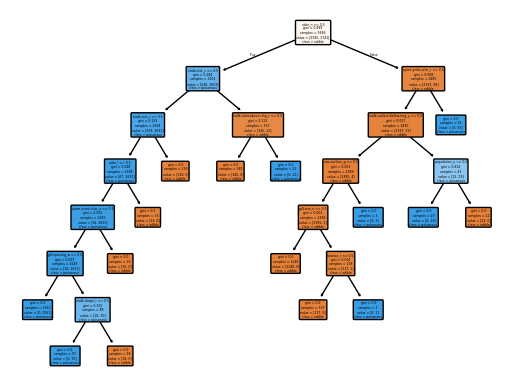

In [16]:

# Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, precision_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree


dt = DecisionTreeClassifier(random_state=42)


param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}


grid = GridSearchCV(
    dt,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)


grid.fit(X_train, y_train)


best_tree = grid.best_estimator_


y_pred = best_tree.predict(X_test)


print("--- DECISION TREE RESULTS ---")
print("Best Params:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


precision_edible = precision_score(y_test, y_pred, pos_label=0)
print("recall (edible, cioè sicurezza nel mangiabile):", precision_edible)

Xcol=list(X.columns)
plot_tree(best_tree,
          feature_names=Xcol,
          class_names=["edible","poisonous"],
          filled=True, rounded=True)
plt.savefig("tree1.png", dpi=300)
plt.show()


In [17]:
#regressione logistica



from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, precision_score


log_reg = LogisticRegression(random_state=42, max_iter=1000)


param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}


grid = GridSearchCV(
    log_reg,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)


grid.fit(X_sel_train, y_train)


best_model = grid.best_estimator_


y_pred = best_model.predict(X_sel_test)


print("--- GLM (LOGISTIC REGRESSION) RESULTS ---")
print("Best Params:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


precision_edible = precision_score(y_test, y_pred, pos_label=0)
print("recall (edible, cioè sicurezza nel mangiabile):", precision_edible)

--- GLM (LOGISTIC REGRESSION) RESULTS ---
Best Params: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1263
           1       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438

recall (edible, cioè sicurezza nel mangiabile): 1.0


In [18]:
#KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_score, accuracy_score, make_scorer

param_grid = {'n_neighbors': list(range(1, 21))}
knn = KNeighborsClassifier()

grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)
grid.fit(X_sel_train, y_train)

best_k = grid.best_params_['n_neighbors']
print(f"Miglior k trovato: {best_k}")


knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_sel_train, y_train)


y_pred = knn_best.predict(X_sel_test)


acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)  # precision per classe positiva = Poison
print(f"Accuracy sul validation set: {acc:.3f}")
print(f"recall (venenoso) sul validation set: {prec:.3f}")

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

print("\nConfusion matrix:\n", cm)
print(f"Sensitivity (TPR): {sensitivity:.3f}")
print(f"Specificity (TNR): {specificity:.3f}")

Miglior k trovato: 1
Accuracy sul validation set: 1.000
recall (venenoso) sul validation set: 1.000

Confusion matrix:
 [[1263    0]
 [   0 1175]]
Sensitivity (TPR): 1.000
Specificity (TNR): 1.000


In [19]:
#XGBoost

from xgboost import XGBClassifier

# Training
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

# Previsione
y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:14:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1263
           1       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



Setup complete.

─────────────────────────────────────────────  Naive Bayes
  Accuracy:  0.9442  |  Precision: 0.9668
  Recall:    0.9157  |  F1 Score:  0.9406


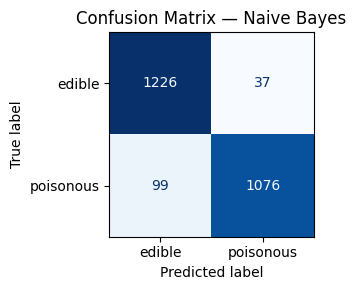

In [20]:
#Naive Bayes

from sklearn.metrics import confusion_matrix, classification_report, precision_score, accuracy_score,recall_score,f1_score, make_scorer
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
def evaluate_clf(name, y_true, y_pred, show_matrix=False):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    print(f"\n{'─'*45}  {name}")
    print(f"  Accuracy:  {acc:.4f}  |  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}  |  F1 Score:  {f1:.4f}")
    if show_matrix:
        fig, ax = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay.from_predictions(
            y_true, y_pred, display_labels=['edible','poisonous'], cmap='Blues', ax=ax, colorbar=False)
        ax.set_title(f'Confusion Matrix — {name}')
        plt.tight_layout()
        plt.show()
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

print("Setup complete.")
from sklearn.naive_bayes import BernoulliNB

clf_nb = BernoulliNB()
clf_nb.fit(X_sel_train, y_train)

y_pred_nb = clf_nb.predict(X_sel_test)

results = [evaluate_clf("Naive Bayes", y_test, y_pred_nb, show_matrix=True)]


Best parameter C: {'classifier__C': 1}

─────────────────────────────────────────────  SVM Tuned Linear
  Accuracy:  1.0000  |  Precision: 1.0000
  Recall:    1.0000  |  F1 Score:  1.0000


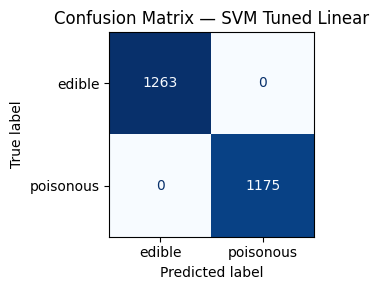

In [22]:
#SVM

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Pipeline minimale: SVM direttamente sui dati già hot-encoded
clf_svm = Pipeline([
    ('classifier', SVC(kernel='linear', random_state=42))
])

# Griglia dei parametri da testare (C = regolarizzazione)
param_grid = {
    'classifier__C': [0.1, 1, 10, 100]
}

# GridSearchCV per trovare il miglior parametro C
grid_search = GridSearchCV(
    estimator=clf_svm,
    param_grid=param_grid,
    cv=5,               # 5-fold cross-validation
    scoring='recall', # ottimizza la precision
    n_jobs=-1           # usa tutti i core disponibili
)

# Allena il modello sul train set
grid_search.fit(X_train, y_train)

# Miglior modello
best_svm = grid_search.best_estimator_
print("Best parameter C:", grid_search.best_params_)

# Previsione sul test set
y_pred_svm = best_svm.predict(X_test)

# Valutazione
results.append(evaluate_clf("SVM Tuned Linear", y_test, y_pred_svm, show_matrix=True))

In [10]:
#analisi su come mai il potere predittivo sia cosi' alto in tutti i modelli

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

print("\nAggregated feature importance:")
print(agg_importance)
plt.figure()
agg_importance.sort_values(ascending=False).plot(kind='bar')

plt.title("Aggregated Feature Importance by Original Variable")
plt.ylabel("Total Importance Score")
plt.xlabel("Features")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("aggregatedF.png", dpi=300)
plt.show()


result = permutation_importance(best_rf, X_test, y_test, n_repeats=10, random_state=42)

# Organizzo i risultati in modo leggibile
perm_importance = pd.Series(result.importances_mean, index=X_test.columns)
perm_importance = perm_importance.sort_values(ascending=False)

print("\nPermutation Feature Importance:")
print(perm_importance)

perm_importance.plot(kind='bar', figsize=(10,5))
plt.title("Permutation Importance")
plt.ylabel("Decrease in accuracy")
plt.savefig("PermutationImp1.png", dpi=300)
plt.show()



plt.figure(figsize=(20,10))
plot_tree(
    best_tree,
    feature_names=X.columns,
    class_names=["edible", "poisonous"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.savefig("tree2.png", dpi=300)
plt.show()

#sembrebbe che odor (in particolare odor_n) sia la variabile più importante, e che abbia un potere predittivo molto alto, tanto da rendere quasi superflue le altre variabili.
#Questo potrebbe spiegare l'elevata performance di tutti i modelli, anche quelli più semplici come il Decision Tree, che riesce a classificare correttamente la maggior parte dei campioni basandosi principalmente su questa singola caratteristica.


Aggregated feature importance:


NameError: name 'agg_importance' is not defined

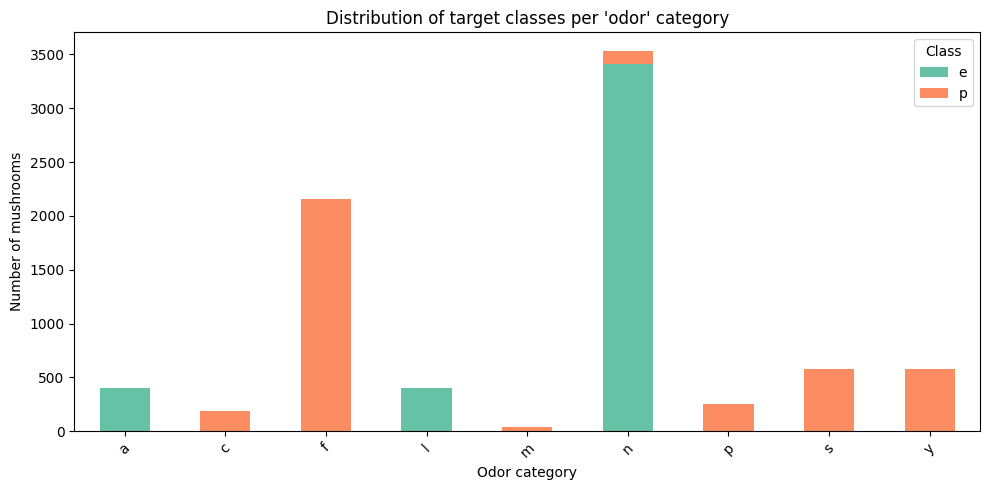

In [24]:
counts = df.groupby(['odor', 'class']).size().unstack(fill_value=0)

# Plot stacked bar
counts.plot(
    kind='bar',
    stacked=True,
    color=['#66c2a5','#fc8d62'],  # edible / poisonous
    figsize=(10,5)
)

plt.title("Distribution of target classes per 'odor' category")
plt.ylabel("Number of mushrooms")
plt.xlabel("Odor category")
plt.xticks(rotation=45)
plt.legend(title="Class")
plt.tight_layout()
plt.show()

Accuracy: 0.9868744872846595
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1263
           1       1.00      0.97      0.99      1175

    accuracy                           0.99      2438
   macro avg       0.99      0.99      0.99      2438
weighted avg       0.99      0.99      0.99      2438



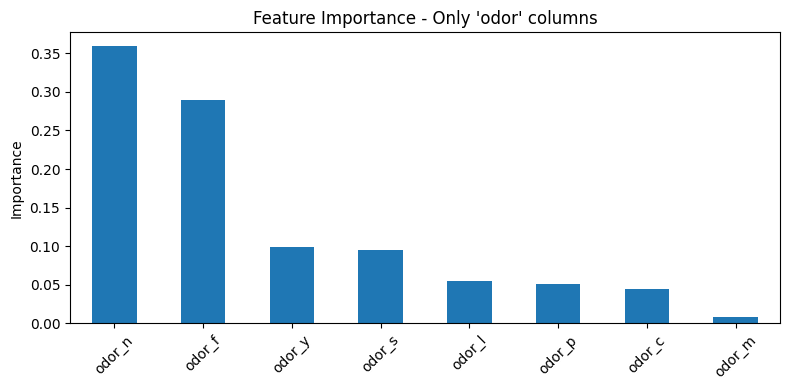

In [25]:
# rf solo con odor

odor_cols = [col for col in X.columns if col.startswith("odor")]
X_odor = X[odor_cols]


X_train_odor, X_test_odor, y_train_odor, y_test_odor = train_test_split(
    X_odor, y, test_size=0.3, random_state=42, stratify=y
)


rf_odor = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)
rf_odor.fit(X_train_odor, y_train_odor)


y_pred = rf_odor.predict(X_test_odor)
print("Accuracy:", accuracy_score(y_test_odor, y_pred))
print(classification_report(y_test_odor, y_pred))


importances = pd.Series(rf_odor.feature_importances_, index=odor_cols)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,4))
importances.plot(kind='bar')
plt.title("Feature Importance - Only 'odor' columns")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Accuracy senza odor: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1263
           1       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



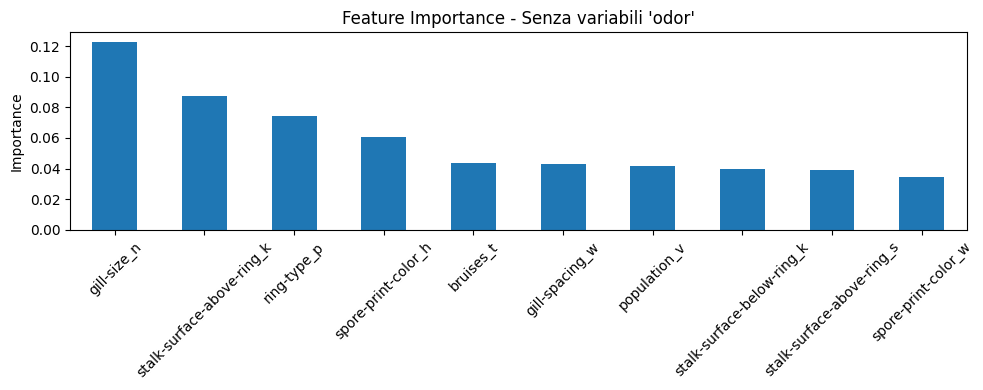

In [26]:
#rf senza odor

non_odor_cols = [col for col in X.columns if not col.startswith("odor")]
X_no_odor = X[non_odor_cols]


X_train_nodor, X_test_nodor, y_train_nodor, y_test_nodor = train_test_split(
    X_no_odor, y, test_size=0.3, random_state=42, stratify=y
)


rf_no_odor = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)
rf_no_odor.fit(X_train_nodor, y_train_nodor)


y_pred = rf_no_odor.predict(X_test_nodor)
print("Accuracy senza odor:", accuracy_score(y_test_nodor, y_pred))
print(classification_report(y_test_nodor, y_pred))


importances = pd.Series(rf_no_odor.feature_importances_, index=non_odor_cols)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,4))
importances.head(10).plot(kind='bar')
plt.title("Feature Importance - Senza variabili 'odor'")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Accuracy (solo odor): 0.9868744872846595
Feature importance (solo odor):
{'odor_c': np.float64(0.05933497799385726), 'odor_f': np.float64(0.020364272445669133), 'odor_l': np.float64(0.15728995883116892), 'odor_m': np.float64(0.015235971552435357), 'odor_n': np.float64(0.6597326211914526), 'odor_p': np.float64(0.036455788060352316), 'odor_s': np.float64(0.03563350769812581), 'odor_y': np.float64(0.015952902226938664)}


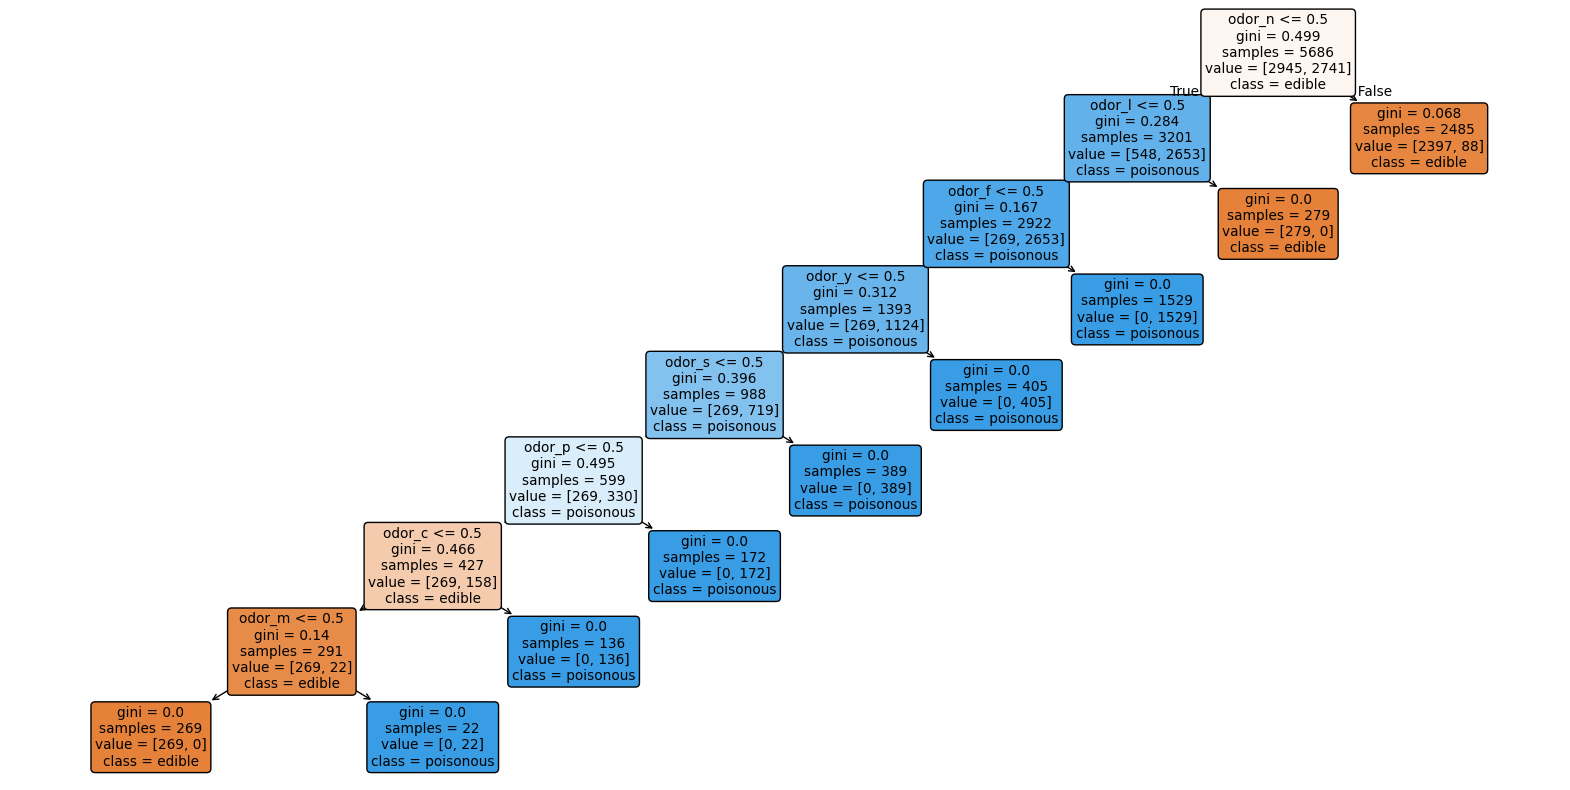

Accuracy (senza odor): 1.0
Feature importance (senza odor):
{'cap-shape_c': np.float64(0.0), 'cap-shape_f': np.float64(0.0), 'cap-shape_k': np.float64(0.0), 'cap-shape_s': np.float64(0.006578662534008051), 'cap-shape_x': np.float64(0.0), 'cap-surface_g': np.float64(0.0), 'cap-surface_s': np.float64(0.0), 'cap-surface_y': np.float64(0.0), 'cap-color_c': np.float64(0.0), 'cap-color_e': np.float64(0.0), 'cap-color_g': np.float64(0.0), 'cap-color_n': np.float64(0.0), 'cap-color_p': np.float64(0.0), 'cap-color_r': np.float64(0.0), 'cap-color_u': np.float64(0.0), 'cap-color_w': np.float64(0.0), 'cap-color_y': np.float64(0.0), 'bruises_t': np.float64(0.013314820793375476), 'gill-spacing_w': np.float64(0.026433931683486928), 'gill-size_n': np.float64(0.2994884573771981), 'gill-color_e': np.float64(0.0), 'gill-color_g': np.float64(0.0), 'gill-color_h': np.float64(0.0), 'gill-color_k': np.float64(0.0), 'gill-color_n': np.float64(0.0), 'gill-color_o': np.float64(0.0), 'gill-color_p': np.float64(0

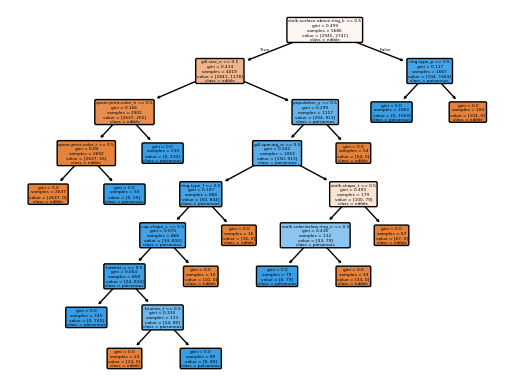

In [27]:
# albero csolo e senza odor

dt_odor = DecisionTreeClassifier(random_state=42)
dt_odor.fit(X_train_odor, y_train_odor)

# valutazione
print("Accuracy (solo odor):", dt_odor.score(X_test_odor, y_test_odor))
print("Feature importance (solo odor):")
print(dict(zip(odor_cols, dt_odor.feature_importances_)))

plt.figure(figsize=(20,10))
plot_tree(dt_odor,
          feature_names=odor_cols,
          class_names=["edible","poisonous"],
          filled=True, rounded=True)
plt.show()


dt_no_odor = DecisionTreeClassifier(random_state=42)
dt_no_odor.fit(X_train_nodor, y_train_nodor)

# valutazione
print("Accuracy (senza odor):", dt_no_odor.score(X_test_nodor, y_test_nodor))
print("Feature importance (senza odor):")
print(dict(zip(non_odor_cols, dt_no_odor.feature_importances_)))

plot_tree(dt_no_odor,
          feature_names=non_odor_cols,
          class_names=["edible","poisonous"],
          filled=True, rounded=True)
plt.show()